Libraries installed successfully..

[PIPELINE] Starting Tabular Data Processing Pipeline...


[ROUTE] Successfully sent to Tabular EDA.


-> Processing data file: 'har_combined.csv'



The shape of the dataset: (10299, 562)
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.288585  -0.020294  -0.132905  -0.995279  -0.983111  -0.913526   
1   0.278419  -0.016411  -0.123520  -0.998245  -0.975300  -0.960322   
2   0.279653  -0.019467  -0.113462  -0.995380  -0.967187  -0.978944   
3   0.279174  -0.026201  -0.123283  -0.996091  -0.983403  -0.990675   
4   0.276629  -0.016570  -0.115362  -0.998139  -0.980817  -0.990482   

   feature_7  feature_8  feature_9  feature_10  ...  feature_553  feature_554  \
0  -0.995112  -0.983185  -0.923527   -0.934724  ...    -0.298676    -0.710304   
1  -0.998807  -0.974914  -0.957686   -0.943068  ...    -0.595051    -0.861499   
2  -0.996520  -0.963668  -0.977469   -0.938692  ...    -0.390748    -0.760104   
3  -0.997099  -0.982750  

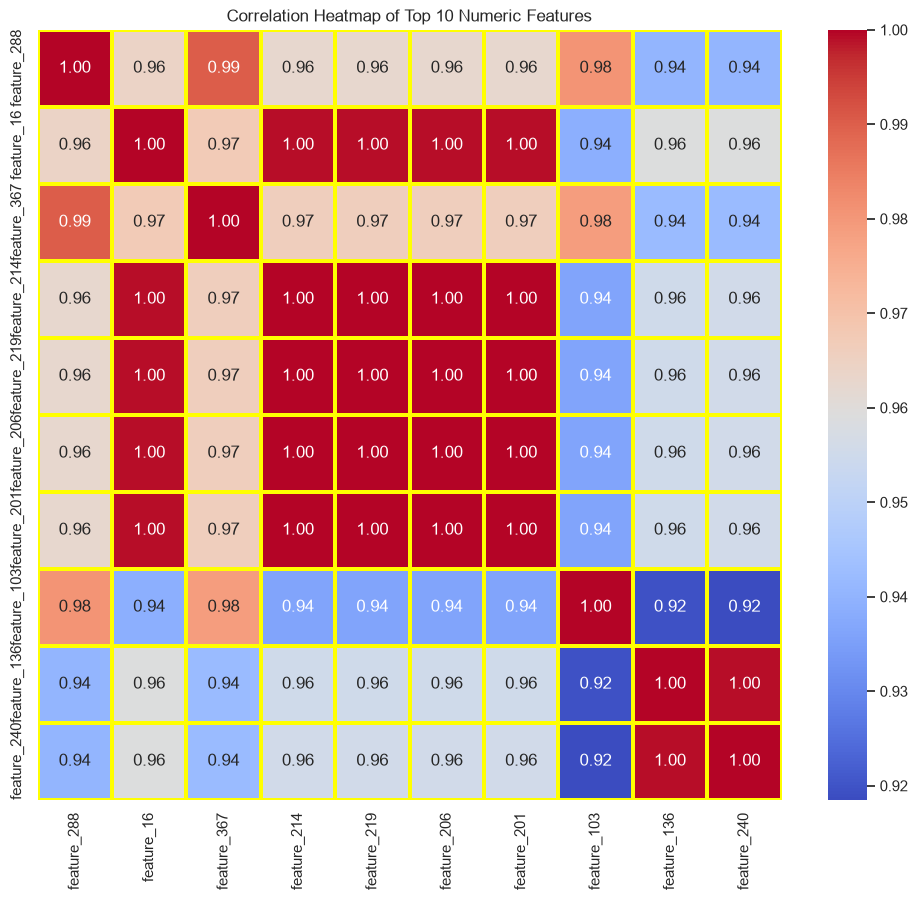



MultiCollinearity analysis skipped for this experiment.


Preprocessing Completed
 Feature Engineering Completed

[PIPELINE COMPLETE]
Final Feature Shape: (10299, 10)
Dataset loaded successfully
Training samples : 7352
Testing samples  : 2947
Total samples    : 10299
Features         : 10

Activity distribution:
activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [7]:
import os
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import importlib
import tabular_pipeline
importlib.reload(tabular_pipeline)

DATASET_PATH = "UCI HAR Dataset.zip"   # Change this to your ZIP/folder path


def find_file(root, filename):
    root = Path(root)
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} was not found inside {root}")
    return matches[0]


def load_har_dataset(dataset_path):
    dataset_path = Path(dataset_path)

    if dataset_path.is_file() and dataset_path.suffix.lower() == ".zip":
        extract_dir = Path(tempfile.mkdtemp(prefix="har_dataset_"))
        with zipfile.ZipFile(dataset_path, "r") as z:
            z.extractall(extract_dir)
        root = extract_dir
    elif dataset_path.is_dir():
        root = dataset_path
    else:
        raise FileNotFoundError(f"Dataset path not found: {dataset_path}")

    x_train_file = find_file(root, "X_train.txt")
    y_train_file = find_file(root, "y_train.txt")
    x_test_file = find_file(root, "X_test.txt")
    y_test_file = find_file(root, "y_test.txt")

    X_train = pd.read_csv(x_train_file, sep=r"\s+", header=None)
    y_train = pd.read_csv(y_train_file, sep=r"\s+", header=None).iloc[:, 0]

    X_test = pd.read_csv(x_test_file, sep=r"\s+", header=None)
    y_test = pd.read_csv(y_test_file, sep=r"\s+", header=None).iloc[:, 0]

    X = pd.concat([X_train, X_test], ignore_index=True)
    y = pd.concat([y_train, y_test], ignore_index=True)

    X.columns = [f"feature_{i+1}" for i in range(X.shape[1])]

    activity_names = {
        1: "WALKING",
        2: "WALKING_UPSTAIRS",
        3: "WALKING_DOWNSTAIRS",
        4: "SITTING",
        5: "STANDING",
        6: "LAYING"
    }

    y_named = y.map(activity_names)

    combined = X.copy()
    combined["activity"] = y_named

    temp_csv = Path(tempfile.mkdtemp(prefix="har_tabular_")) / "har_combined.csv"
    combined.to_csv(temp_csv, index=False)

    pipeline_result = tabular_pipeline.tabular_pipeline(
        str(temp_csv),
        target_col="activity",
        task_type="classification",
        method="hybrid",
        k=0,
        variance_threshold=0.0,
        random_state=42,
        run_vif=False,
        run_univariate=False
    )

    X_processed = pipeline_result["X"].copy()
    y_processed = pipeline_result["y"].copy()

    if isinstance(y_processed, pd.Series):
        y_processed = y_processed.reset_index(drop=True)
    else:
        y_processed = pd.Series(y_processed)

    X_processed = pd.DataFrame(X_processed).reset_index(drop=True)

    return X_processed, y_processed, X_train, X_test, y_train, y_test


X, y, X_train, X_test, y_train, y_test = load_har_dataset(DATASET_PATH)

print("Dataset loaded successfully")
print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])
print("Total samples    :", X.shape[0])
print("Features         :", X.shape[1])
print("\nActivity distribution:")
print(y.value_counts())

Missing values: 0
Dataset shape: (10299, 10)
PCA explained variance:
PC1: 74.71%
PC2: 7.57%
Total: 82.28%


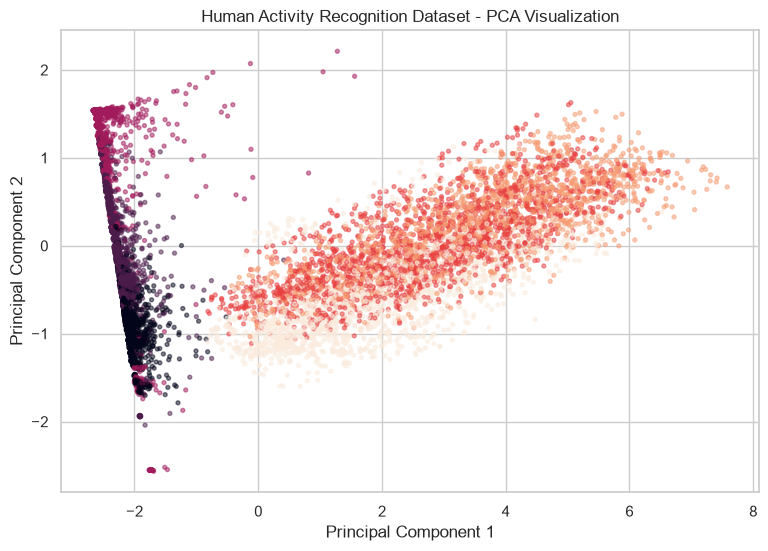

In [8]:
# Cell 2: Perform basic EDA and reduce the data to two PCA components for visualization

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Recover gracefully if this cell is run after an older pipeline execution
# that produced an empty processed feature matrix.
if X.shape[1] == 0:
    X = pd.concat([X_train, X_test], ignore_index=True)
    X.columns = [f"feature_{i+1}" for i in range(X.shape[1])]
    print("Processed features were empty; using the original HAR feature matrix for PCA.")

print("Missing values:", X.isnull().sum().sum())
print("Dataset shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

print("PCA explained variance:")
print(f"PC1: {pca_2d.explained_variance_ratio_[0] * 100:.2f}%")
print(f"PC2: {pca_2d.explained_variance_ratio_[1] * 100:.2f}%")
print(f"Total: {pca_2d.explained_variance_ratio_.sum() * 100:.2f}%")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pd.factorize(y)[0],
    s=8,
    alpha=0.5
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Human Activity Recognition Dataset - PCA Visualization")
plt.show()


Table 1: K-Means Elbow Method Results
 Number of Clusters (k)  WCSS (Inertia)  Silhouette Score
                      2    38422.190794          0.563092
                      3    28209.107338          0.492036
                      4    22822.218780          0.466211
                      5    20381.417969          0.445630
                      6    18575.101475          0.447049
                      7    17687.616541          0.431532
                      8    16960.561525          0.432077

Selected k based on highest Silhouette Score: 2


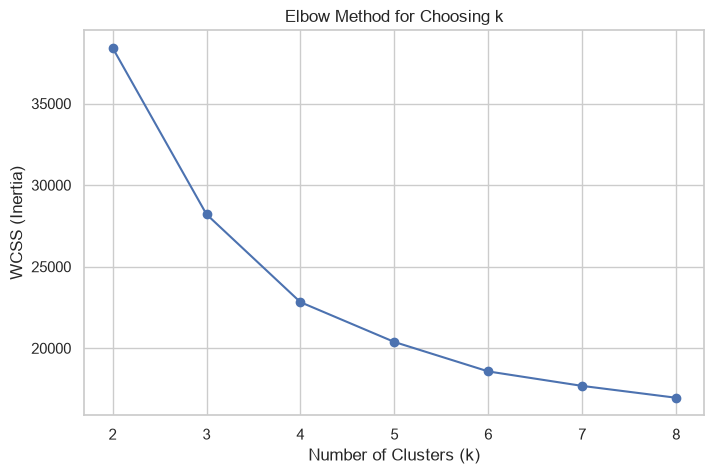

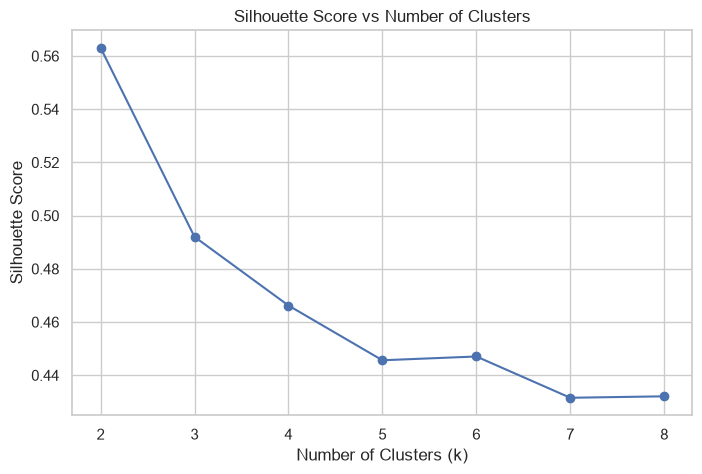

In [9]:
# Cell 3: Determine the K-Means cluster count using WCSS and Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

kmeans_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    wcss = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, cluster_labels)

    kmeans_results.append([
        k,
        wcss,
        silhouette
    ])

kmeans_table = pd.DataFrame(
    kmeans_results,
    columns=[
        "Number of Clusters (k)",
        "WCSS (Inertia)",
        "Silhouette Score"
    ]
)

print("\nTable 1: K-Means Elbow Method Results")
print(kmeans_table.to_string(index=False))

best_k = kmeans_table.loc[
    kmeans_table["Silhouette Score"].idxmax(),
    "Number of Clusters (k)"
]

print(f"\nSelected k based on highest Silhouette Score: {int(best_k)}")


plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_table["Number of Clusters (k)"],
    kmeans_table["WCSS (Inertia)"],
    marker="o"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Choosing k")
plt.xticks(k_values)
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_table["Number of Clusters (k)"],
    kmeans_table["Silhouette Score"],
    marker="o"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.grid(True)
plt.show()


Clustering Evaluation Results
          Algorithm  Number of Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index  Adjusted Rand Index (ARI)  Normalized Mutual Information (NMI)
            K-Means                   2          0.563092              0.718777             17303.925613                   0.278884                             0.445425
             DBSCAN                  15          0.391480              0.966102               276.423574                   0.068863                             0.251445
Hierarchical (Ward)                   2          0.555193              0.717696             16464.496351                   0.331934                             0.553713

DBSCAN cluster information
Number of noise points: 4516
Number of clusters: 15


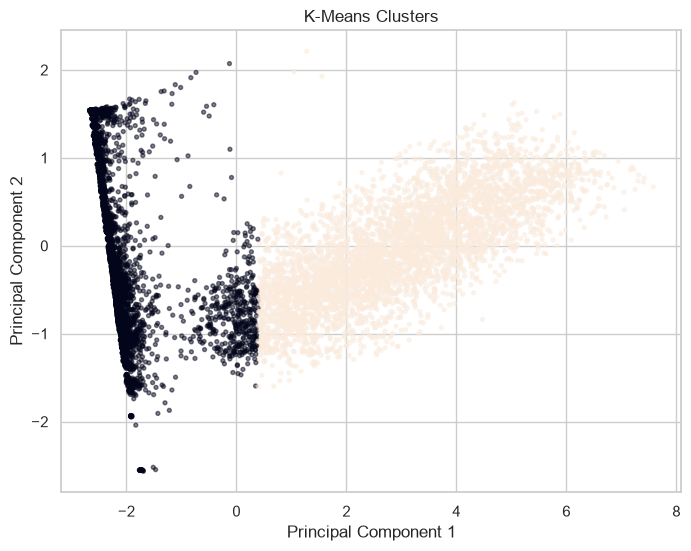

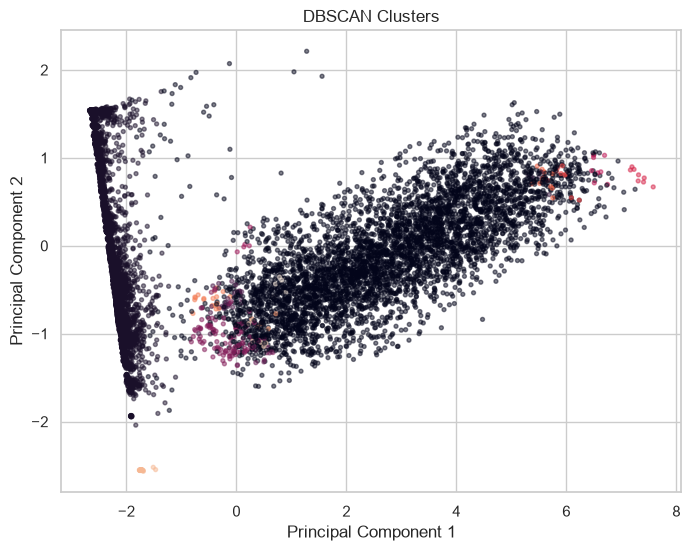

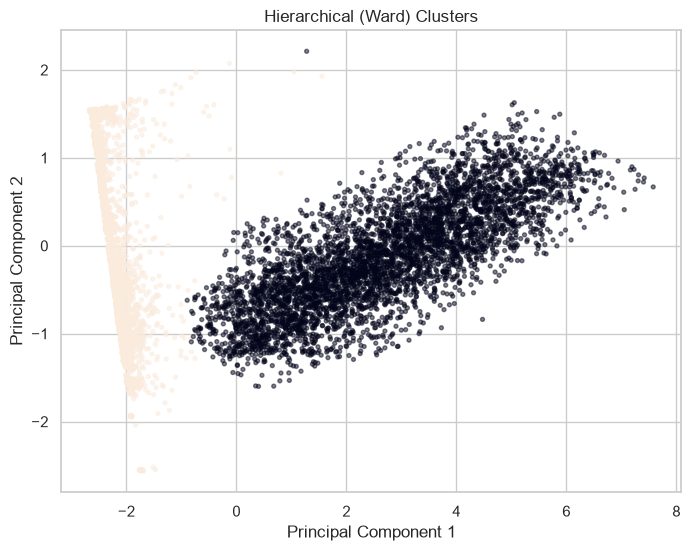

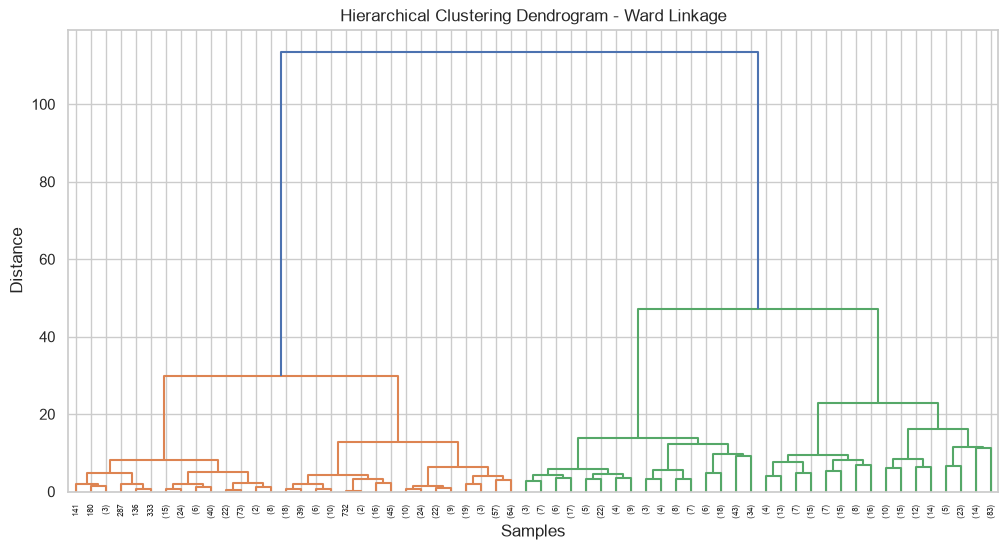

In [10]:
# Cell 4: Train K-Means, DBSCAN and Ward Hierarchical Clustering and calculate clustering metrics

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

# K-Means
kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)

# DBSCAN
dbscan_eps = 0.5
dbscan_min_samples = 5

dbscan = DBSCAN(
    eps=dbscan_eps,
    min_samples=dbscan_min_samples
)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Ward Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=int(best_k),
    linkage="ward"
)
hierarchical_labels = hierarchical.fit_predict(X_scaled)


def evaluate_clustering(name, labels):
    mask = labels != -1

    valid_X = X_scaled[mask]
    valid_labels = labels[mask]
    valid_y = np.asarray(y)[mask]

    number_of_clusters = len(set(valid_labels))

    if number_of_clusters < 2:
        return [
            name,
            number_of_clusters,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan
        ]

    silhouette = silhouette_score(valid_X, valid_labels)
    davies = davies_bouldin_score(valid_X, valid_labels)
    calinski = calinski_harabasz_score(valid_X, valid_labels)
    ari = adjusted_rand_score(valid_y, valid_labels)
    nmi = normalized_mutual_info_score(valid_y, valid_labels)

    return [
        name,
        number_of_clusters,
        silhouette,
        davies,
        calinski,
        ari,
        nmi
    ]


results = [
    evaluate_clustering("K-Means", kmeans_labels),
    evaluate_clustering("DBSCAN", dbscan_labels),
    evaluate_clustering("Hierarchical (Ward)", hierarchical_labels)
]

metrics_table = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Number of Clusters",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Adjusted Rand Index (ARI)",
        "Normalized Mutual Information (NMI)"
    ]
)

print("\nClustering Evaluation Results")
print(metrics_table.to_string(index=False))


print("\nDBSCAN cluster information")
print("Number of noise points:", np.sum(dbscan_labels == -1))
print(
    "Number of clusters:",
    len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)


# PCA cluster visualizations
figures = [
    ("K-Means", kmeans_labels),
    ("DBSCAN", dbscan_labels),
    ("Hierarchical (Ward)", hierarchical_labels)
]

for title, labels in figures:
    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        s=8,
        alpha=0.5
    )
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"{title} Clusters")
    plt.show()


# Dendrogram
sample_size = min(1000, X_scaled.shape[0])
sample_indices = np.random.RandomState(42).choice(
    X_scaled.shape[0],
    sample_size,
    replace=False
)

linkage_matrix = linkage(
    X_scaled[sample_indices],
    method="ward"
)

plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5
)
plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [11]:
# Cell 5: Compare hierarchical linkage methods and prepare the final observations

linkage_results = []

for method in ["single", "complete", "average", "ward"]:

    hierarchical_model = AgglomerativeClustering(
        n_clusters=int(best_k),
        linkage=method
    )

    labels = hierarchical_model.fit_predict(X_scaled)

    linkage_results.append([
        method,
        silhouette_score(X_scaled, labels),
        davies_bouldin_score(X_scaled, labels),
        calinski_harabasz_score(X_scaled, labels),
        adjusted_rand_score(y, labels),
        normalized_mutual_info_score(y, labels)
    ])

linkage_table = pd.DataFrame(
    linkage_results,
    columns=[
        "Linkage",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Adjusted Rand Index (ARI)",
        "Normalized Mutual Information (NMI)"
    ]
)

print("\nHierarchical Clustering Linkage Comparison")
print(linkage_table.to_string(index=False))


best_kmeans_silhouette = kmeans_table["Silhouette Score"].max()
best_kmeans_k = kmeans_table.loc[
    kmeans_table["Silhouette Score"].idxmax(),
    "Number of Clusters (k)"
]

best_algorithm = metrics_table.loc[
    metrics_table["Silhouette Score"].idxmax(),
    "Algorithm"
]

print("\nFinal Summary")
print("Best K-Means k:", int(best_kmeans_k))
print("Best K-Means Silhouette Score:", round(best_kmeans_silhouette, 4))
print("Highest Silhouette Score Algorithm:", best_algorithm)
print("DBSCAN Noise Points:", int(np.sum(dbscan_labels == -1)))


Hierarchical Clustering Linkage Comparison
 Linkage  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index  Adjusted Rand Index (ARI)  Normalized Mutual Information (NMI)
  single          0.220506              0.755565                 1.536944                  -0.000009                             0.000181
complete          0.528674              0.783578             13975.990994                   0.173224                             0.310987
 average          0.555421              0.717460             16486.555393                   0.332281                             0.555574
    ward          0.555193              0.717696             16464.496351                   0.331934                             0.553713

Final Summary
Best K-Means k: 2
Best K-Means Silhouette Score: 0.5631
Highest Silhouette Score Algorithm: K-Means
DBSCAN Noise Points: 4516
